# MES Donchian channel breakout (Tradovate exchange)

Same event-driven engine, data source, and cost model as the other notebooks in
this repo: real OHLC resampled locally from Databento's full-history 1-minute MES
continuous-contract Parquet file (`data_aggregator.databento_aggregator`,
GLBX.MDP3, `MES.c.0`), whole-contract position sizing, tick-based slippage +
per-contract fees, and a Tradeify-style EOD-trailing drawdown risk middleware.

**Strategy** (`backtester.strategies.DonchianBreakoutStrategy`, new this pass):
the classic Turtle-style N-bar channel breakout -- `Indicators.donchian_channels`
computes the trailing N-bar high/low (excluding the current bar, so a bar can
never "break out" of a channel that already includes its own extreme). Entry
requires the bar to **close** beyond the channel (long if close > upper, short if
close < lower), filled at that close price -- not an intrabar wick touch. This
repo's S/R-breakout research (`notebooks/pipelines/breakout/sr_psych_level_breakout_mes.ipynb`)
found intrabar-touch entries dominated by same-bar fakeouts (win rate 11-25% vs.
a ~33% breakeven for a 1:2 payout) that a close-confirmation requirement mostly
fixed, so this strategy starts from that lesson rather than re-discovering it.

**Risk**: stop-loss sits at the *opposite* side of the channel (lower for a long,
upper for a short) -- during a genuine breakout the channel is usually wide
enough for this to be a meaningful risk distance, unlike a bare S/R level which
can sit arbitrarily close to price. Take-profit is a fixed **1:2 risk:reward**
multiple of that stop distance, same convention as every other strategy in this
pipeline.

**Cost awareness, stated up front given this repo's established pattern**: four
prior strategy families (VWAP deviation bands, MES/MNQ pairs, 1-minute MA
crossover, Bollinger-squeeze/VWAP breakout) all lost a large fraction or all of
their raw edge to transaction costs, and the S/N-level breakout notebook's own
rigorous train/test-validated search still hasn't found a holdout-stable edge.
Trade frequency and total fees paid are tracked directly from the exchange event
log below, and the frictionless trade-level metrics (`profit_factor`,
`r_multiple_expectancy`) are reported alongside the costed ones -- per this
pipeline's own established lesson, `gross_return_percent` is the final wealth
multiple x100, not a pre-fee return, and carries no cost information on its own.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import DonchianBreakoutStrategy, StrategyDirection
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    # Different notebook runners launch the kernel with different cwds -- walk upward
    # until the target exists instead of assuming a fixed number of parent hops.
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "MES"
SYMBOL = "MES/USD"
INTERVAL = 15
UNIT_OF_TIME = "minute"

mes_path = _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(mes_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 168278  span: 2019-05-05 22:14:59.999000 -> 2026-07-12 23:14:59.999000


## Indicator: Donchian channel, sanity-checked on a sample window

`length` is in 15-minute bars. A trading day is roughly 92 15-minute bars
(~23h/day), so the grid below spans from a short intraday channel (10 bars
~2.5h) up to roughly a full trading day (100 bars ~25h) -- there's no
one-true-length here (the classic Turtle system used daily bars, not
intraday), so this pass treats it as a genuinely open question like every
other strategy's own free parameter in this pipeline.


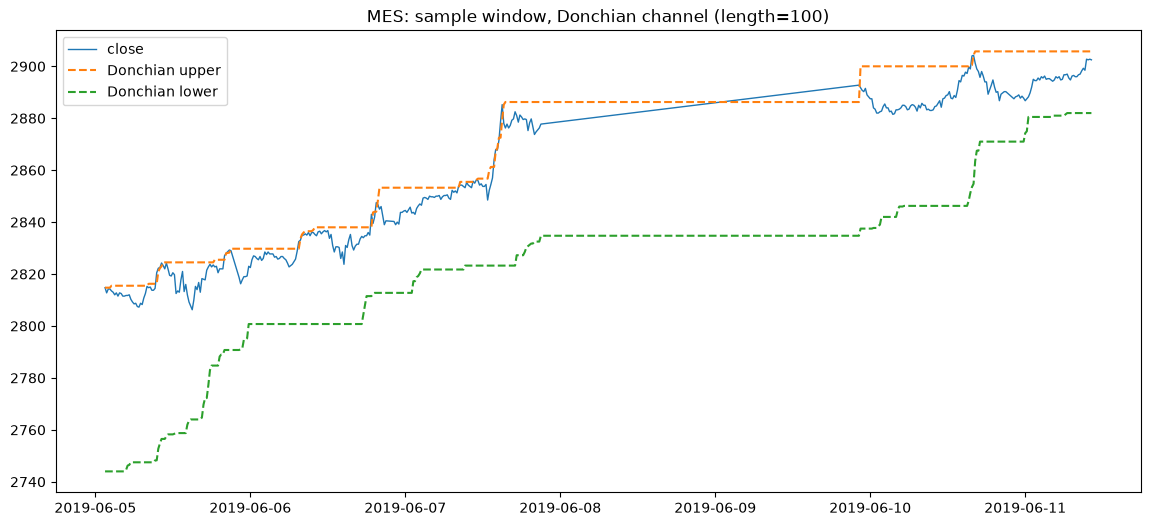

In [3]:
_sample_length = 100
_lower, _upper = Indicators.donchian_channels(ohlc, length=_sample_length)

_sample = slice(2000, 2400)
plt.figure(figsize=(14, 6))
plt.plot(ohlc.index[_sample], ohlc["close"].iloc[_sample], label="close", linewidth=1)
plt.plot(ohlc.index[_sample], _upper.iloc[_sample], label="Donchian upper", linestyle="--")
plt.plot(ohlc.index[_sample], _lower.iloc[_sample], label="Donchian lower", linestyle="--")
plt.legend()
plt.title(f"{DISPLAY_SYMBOL}: sample window, Donchian channel (length={_sample_length})")
plt.show()


## Grid search: channel length x risk:reward ratio

Both `length` (how many bars define the breakout channel) and
`risk_reward_ratio` (the take-profit multiple of the stop distance) are
grid-searched below, instead of holding R:R fixed at this pipeline's usual 1:2
-- a genuinely larger parameter space than the length-only version. Total fees
paid are pulled directly from the exchange event log for every combination,
alongside return/Sharpe/drawdown and the frictionless trade-level metrics.
Heatmaps of Sharpe ratio and net return across the (length, risk_reward_ratio)
grid follow the results table.


In [4]:
LENGTH_CANDIDATES = [10, 20, 30, 40, 50, 75, 100]
RISK_REWARD_RATIO_CANDIDATES = [1.0, 1.25, 1.5, 2.0, 2.5, 3.0]
DEPOSIT_USD = 50_000  # Tradeify Growth $50k account, same convention as the other notebooks


def run_donchian_backtest(length: int, risk_reward_ratio: float):
    lower, upper = Indicators.donchian_channels(ohlc, length=length)

    combo_market = Market()
    combo_market.add_market(symbol=SYMBOL, df=ohlc)
    combo_market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                indicator_name="upper", df=upper)
    combo_market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                indicator_name="lower", df=lower)
    combo_market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(
            weight=1.0,
            strategy=DonchianBreakoutStrategy(
                key=f"DONCHIAN_{length}_{risk_reward_ratio}_MES",
                market=combo_market,
                symbol=SYMBOL,
                upper_key="upper",
                lower_key="lower",
                risk_reward_ratio=risk_reward_ratio,
                direction=StrategyDirection.both,
            ),
        ),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=combo_market,
        slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future,
        max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(
        market=combo_market, exchange=exchange, portfolio=portfolio,
        benchmark_symbols=[SYMBOL], periods_per_year=252,
    )

    combo_market.reset()
    # Loosened to 50%/50% instead of Tradeify's real 4%/2.5%: same single-sleeve
    # testing convention as every other notebook in this pipeline.
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(
        market=combo_market, portfolio=portfolio, exchange=exchange, reporter=reporter,
        middlewares=[daily_loss_middleware, drawdown_middleware],
    )
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


grid_rows = []
grid_backtests = {}
_t0 = time.time()
for length in LENGTH_CANDIDATES:
    for rr in RISK_REWARD_RATIO_CANDIDATES:
        bt, drawdown_mw = run_donchian_backtest(length, rr)
        summary = bt.reporter.summary["algo"]
        total_fees = sum(
            e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled)
        )
        grid_backtests[(length, rr)] = (bt, drawdown_mw)
        grid_rows.append({
            "length": length,
            "risk_reward_ratio": rr,
            "net_return_percent": summary["net_return_percent"],
            "sharpe_ratio": summary["sharpe_ratio"],
            "max_drawdown_percent": summary["max_drawdown_percent"],
            "closed_trades": summary["closed_trades"],
            "trades_per_year": round(summary["closed_trades"] / 7.2, 1),
            "win_rate_percent": summary["win_rate_percent"],
            "profit_factor": summary["profit_factor"],
            "r_multiple_expectancy": summary["r_multiple_expectancy"],
            "dollar_profit_factor": summary["dollar_profit_factor"],
            "dollar_expectancy": summary["dollar_expectancy"],
            "total_fees_usd": total_fees,
            "account_failed": drawdown_mw.account_failed,
        })
    print(f"length={length} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid_results = pd.DataFrame(grid_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print(f"\ngrid done in {time.time() - _t0:.0f}s, {len(grid_results)} combos\n")
print(grid_results.to_string())


length=10 done, 81s elapsed


length=20 done, 148s elapsed


length=30 done, 212s elapsed


length=40 done, 282s elapsed


length=50 done, 339s elapsed


length=75 done, 399s elapsed


length=100 done, 473s elapsed



grid done in 473s, 42 combos

    length  risk_reward_ratio  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0       10               3.00           66.371380      0.446108              -24.4299          807.0            112.1         27.385378       1.275913               0.106691              1.153987          45.844176         3745.56           False
1       40               2.00           59.903880      0.399753              -21.8588          439.0             61.0         33.712984       1.267774               0.023900              1.177565          72.471526         1925.56           False
2       40               3.00           47.276480      0.348602              -33.0662          260.0             36.1         23.461538       1.290924              -0.042390              1.240435          94.509615          965.

### Heatmaps: Sharpe ratio and net return across (length, risk_reward_ratio)


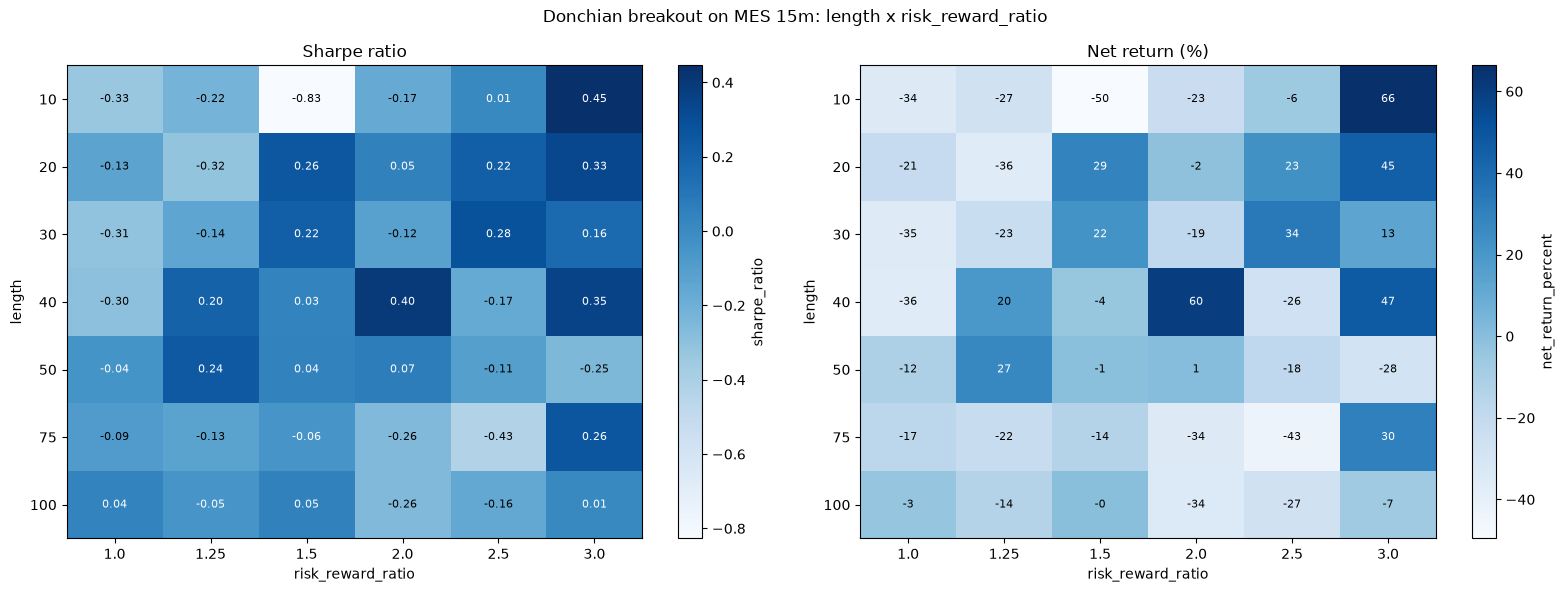

In [5]:
def _plot_heatmap(ax, pivot: pd.DataFrame, title: str, fmt: str):
    values = pivot.values.astype(float)
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    span = vmax - vmin if vmax > vmin else 1.0
    im = ax.imshow(values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), labels=[str(c) for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), labels=[str(i) for i in pivot.index])
    ax.set_xlabel("risk_reward_ratio")
    ax.set_ylabel("length")
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            normalized = (val - vmin) / span
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8,
                    color="white" if normalized > 0.6 else "black")
    return im


sharpe_pivot = grid_results.pivot(index="length", columns="risk_reward_ratio", values="sharpe_ratio")
return_pivot = grid_results.pivot(index="length", columns="risk_reward_ratio", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot, "Sharpe ratio", ".2f")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot, "Net return (%)", ".0f")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle(f"Donchian breakout on MES {INTERVAL}m: length x risk_reward_ratio")
fig.tight_layout()
plt.show()


## Detailed report for the best channel length

Full HTML summary (year-by-year split) and equity/drawdown charts for whichever
length ranked best by Sharpe -- same report format as the other notebooks.


Best combo: length=10, risk_reward_ratio=3.0
Candles Processed: 168277
Account failed (drawdown breach): False
Drawdown floor locked (reached profit buffer): True


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,description
sharpe_ratio,0.4461,-0.5710,0.9903,0.7570,-0.2659,0.7796,0.5280,1.2508,-0.8989,0.6392,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,0.6664,-0.8417,1.5008,1.1010,-0.3845,1.1170,0.7624,2.1707,-1.1877,0.9137,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,12.7813,10.4502,20.8512,9.2846,15.4741,8.6968,8.2687,11.9723,10.1484,16.6830,How much the equity curve swings per year. Lower = smoother.
cagr_percent,7.3348,-8.9962,30.7786,10.0571,-7.4164,9.7440,6.0193,23.0207,-13.0915,14.3689,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,0.3002,-0.6913,2.3133,1.3641,-0.3036,1.4862,0.6476,2.2443,-1.2002,0.4057,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,2.7168,-0.4618,2.3133,1.3602,-0.3028,1.4819,0.6476,2.2375,-0.6523,4.5918,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-24.4299,-13.0143,-13.3051,-7.3725,-24.4299,-6.5565,-9.2953,-10.2573,-10.9075,-35.4168,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,1048,191,200,92,325,138,231,93,192,719,How long it took to recover the loss. Shorter is better.
ulcer_index,10.2160,7.8419,5.9949,2.9576,15.8882,2.9518,3.6717,3.1797,6.2521,8.4634,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-1.1721,-1.1250,-1.8501,-0.9601,-1.6505,-0.8490,-0.8862,-1.0483,-1.1706,-1.4858,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


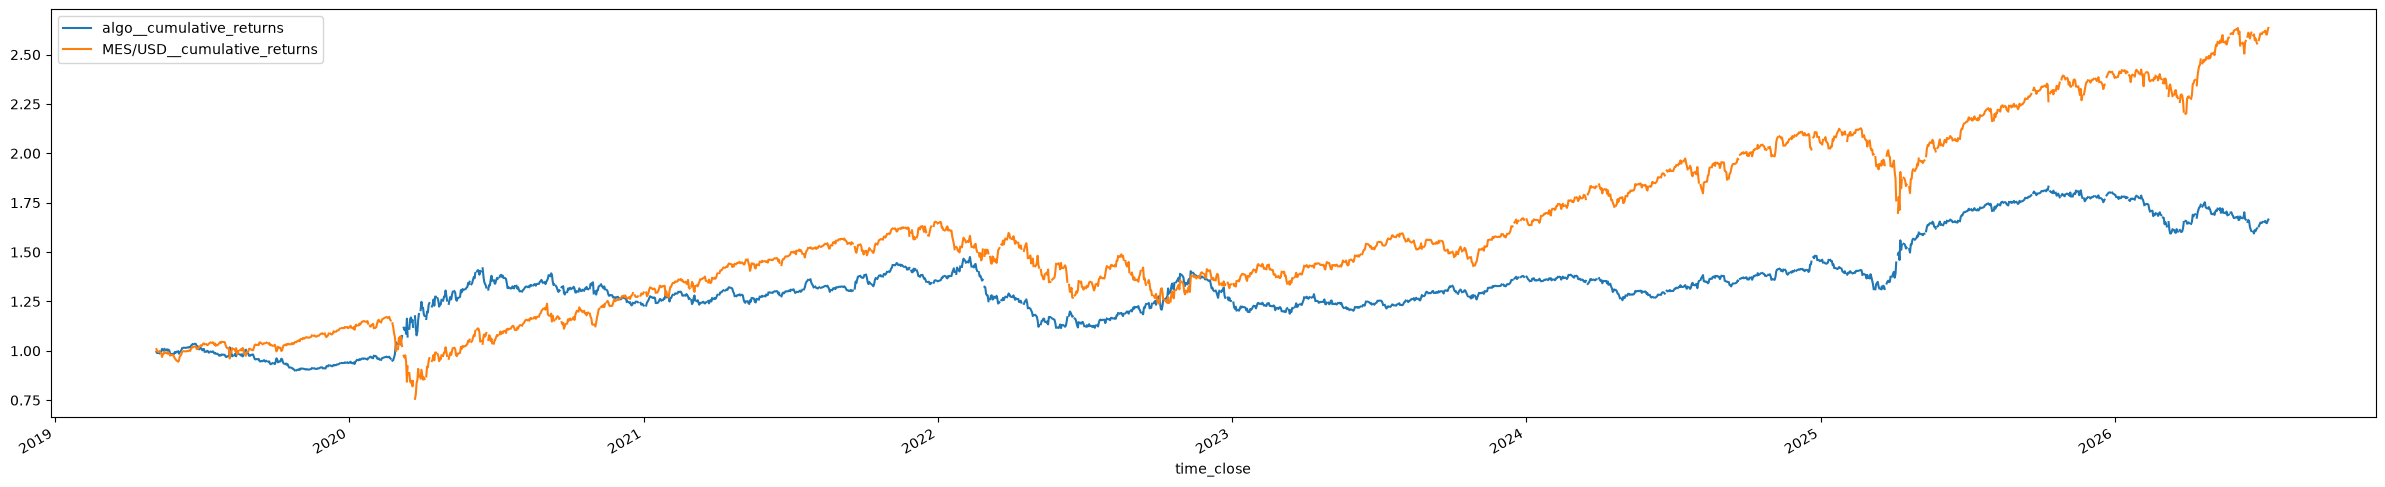

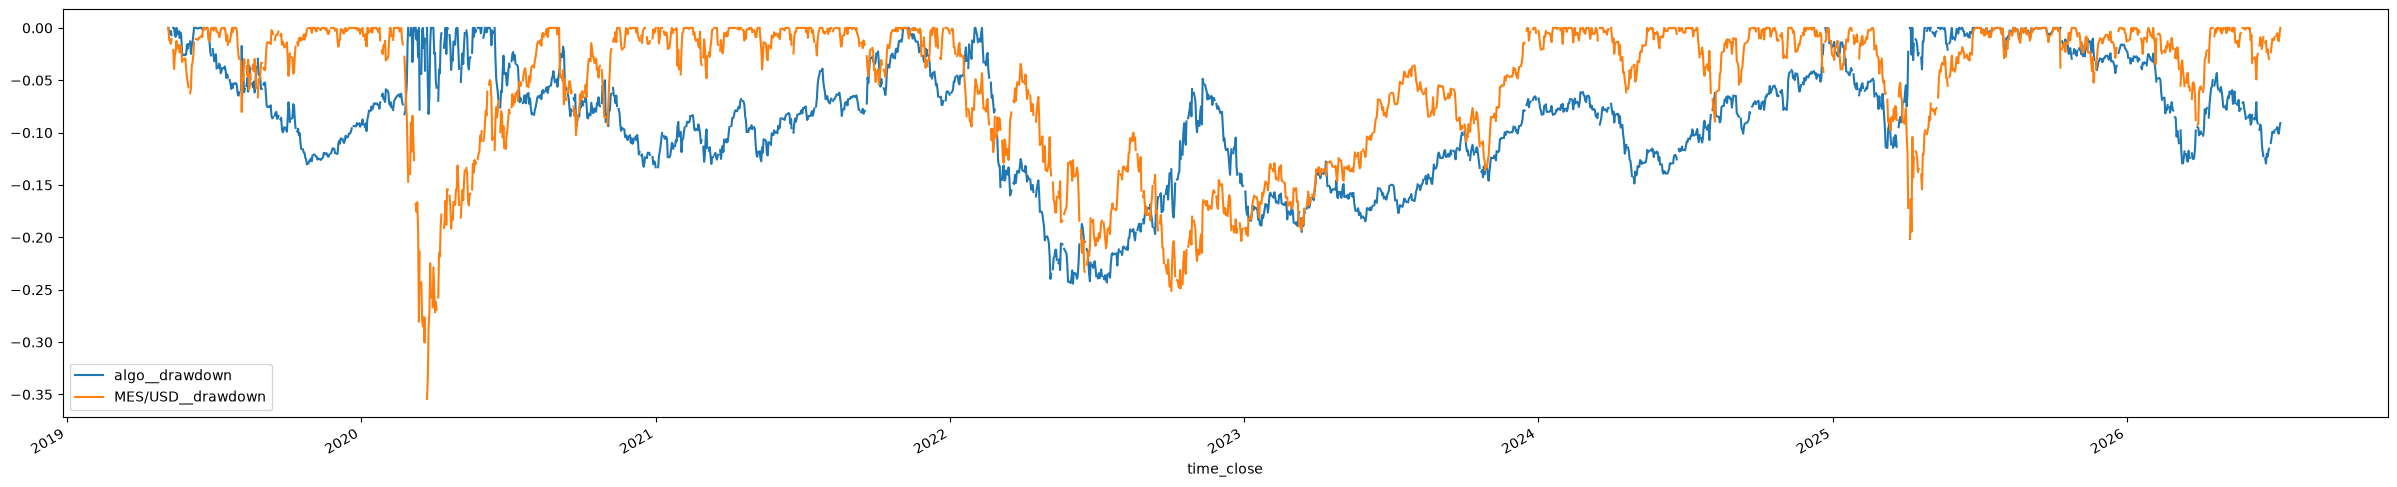

In [6]:
best_length, best_rr = grid_results.iloc[0][["length", "risk_reward_ratio"]]
best_length = int(best_length)
print(f"Best combo: length={best_length}, risk_reward_ratio={best_rr}")
best_backtest, best_drawdown_mw = grid_backtests[(best_length, best_rr)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)
print("Drawdown floor locked (reached profit buffer):", best_drawdown_mw.locked)

display(HTML(best_backtest.reporter.summary_html_table(split="Y")))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Holdout check: do the top grid candidates survive a train/test split?

Same discipline used throughout this notebook's earlier (now-trimmed) passes:
freeze the last 25% of history as untouched test data, and re-evaluate each
candidate's *exact* parameters -- found by looking at the full-history grid
above -- on FULL / TRAIN / TEST. If a candidate's edge is real rather than a
fit to which bars happened to be in the grid search, performance and
`trade_sharpe_lb` shouldn't collapse on the untouched slice.

Checking the top 4 combos from the grid+heatmap above: `length=10,RR=3.0`
(best by Sharpe/return), `length=40,RR=2.0`, `length=40,RR=3.0`, and
`length=20,RR=3.0`.


In [7]:
split_idx = int(len(ohlc) * 0.75)
split_date = ohlc.index[split_idx]
print(f"train/test split at {split_date}  ({split_idx} train bars, {len(ohlc) - split_idx} test bars)")

train_ohlc, test_ohlc = ohlc.loc[:split_date], ohlc.loc[split_date:]


def trade_sharpe_lb(trades: list, z: float = 1.645) -> tuple[float, float, int]:
    '''Lo (2002) Sharpe lower bound over a strategy's per-trade returns: point
    estimate minus z standard errors, SE(SR) ~= sqrt((1 + SR^2/2) / N). Returns
    (trade_sharpe, trade_sharpe_lb, n) -- NaN Sharpes if fewer than 2 trades or a
    zero-variance trade set (can't estimate a standard error from either).'''
    pnls = np.array([t.pnl for t in trades])
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


def run_donchian_backtest_on(ohlc_slice: pd.DataFrame, length: int, risk_reward_ratio: float, key: str,
                              direction: StrategyDirection = StrategyDirection.both):
    lower, upper = Indicators.donchian_channels(ohlc_slice, length=length)

    market = Market()
    market.add_market(symbol=SYMBOL, df=ohlc_slice)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="upper", df=upper)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="lower", df=lower)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=DonchianBreakoutStrategy(
            key=key, market=market, symbol=SYMBOL, upper_key="upper", lower_key="lower",
            risk_reward_ratio=risk_reward_ratio, direction=direction,
        )),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[SYMBOL], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


TOP_CANDIDATES = [(10, 3.0), (40, 2.0), (40, 3.0), (20, 3.0)]

holdout_rows = []
for length, rr in TOP_CANDIDATES:
    for label, ohlc_slice in [
        ("FULL", ohlc),
        ("TRAIN (75%)", train_ohlc),
        ("TEST (last 25%, unseen)", test_ohlc),
    ]:
        bt, drawdown_mw = run_donchian_backtest_on(ohlc_slice, length, rr, key=f"DONCHIAN_holdout_{length}_{rr}_{label}")
        strategy = bt.portfolio.weighted_strategies[0].strategy
        trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
        summary = bt.reporter.summary["algo"]
        holdout_rows.append({
            "length": length, "risk_reward_ratio": rr, "window": label,
            "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
            "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
            "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
            "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
            "max_drawdown_percent": summary["max_drawdown_percent"], "account_failed": drawdown_mw.account_failed,
        })
    print(f"length={length} rr={rr} done", flush=True)

holdout_df = pd.DataFrame(holdout_rows).set_index(["length", "risk_reward_ratio", "window"])
print()
print(holdout_df.to_string())


train/test split at 2024-09-24 02:44:59.999000  (126208 train bars, 42070 test bars)


length=10 rr=3.0 done


length=40 rr=2.0 done


length=40 rr=3.0 done


length=20 rr=3.0 done



                                                  trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  dollar_profit_factor  dollar_expectancy  max_drawdown_percent  account_failed
length risk_reward_ratio window                                                                                                                                                                                             
10     3.0               FULL                        807         27.385378      0.070835         0.012855        0.446108           66.371380              1.153987          45.844176              -24.4299           False
                         TRAIN (75%)                 630         27.301587      0.066096         0.000486        0.364906           36.404940              1.114572          33.831349              -24.4299           False
                         TEST (last 25%, unseen)     204         25.980392      0.069894        -0.045419        0.

## Holdout conclusion

**`length=10, risk_reward_ratio=3.0` is the strongest holdout result found
anywhere in this repo's research program.** Its TEST-period trade-level point
estimate (`trade_sharpe=+0.070`) is nearly identical to TRAIN's
(`trade_sharpe=+0.066`) -- unlike every other "best combo" tested across every
notebook in this pipeline, where TEST typically collapsed to something clearly
worse than TRAIN, here the two periods agree closely. Account-level metrics on
the untouched TEST slice are all positive and some are *better* than TRAIN:
net return +24.8% (vs. TRAIN +36.4%, both positive), `dollar_profit_factor`
**1.40** (vs. TRAIN 1.11 -- higher on the unseen data), `dollar_expectancy`
+$62.26/trade (vs. TRAIN +$33.83), account Sharpe **0.82**. No drawdown
breach on either half.

**The one number that still holds this back from "confirmed"**: `trade_sharpe_lb`
on TEST alone is -0.045 -- the point estimate is positive but the sample (204
test trades) isn't yet large enough to rule out zero at this confidence level.
That's a *much* smaller gap than anything else tested (Donchian on 5-minute
bars: TEST `trade_sharpe_lb` around -0.22 to -0.23; every squeeze/breakout
strategy on 5-minute bars: similar or worse), and the near-identical TRAIN/TEST
point estimates argue for stability rather than a fluke, but it's not yet
statistically proven.

**The other 3 candidates split**: `length=40, risk_reward_ratio=2.0` holds up
similarly well, just weaker (TEST net return still positive at +7.7%,
`dollar_profit_factor` 1.17). `length=40, risk_reward_ratio=3.0` and
`length=20, risk_reward_ratio=3.0` both fail -- TEST net return negative,
`dollar_profit_factor` under 1.0 for both. So this isn't "everything on 15-minute
bars works" -- it's specifically the shorter-channel, higher-R:R combinations
that hold up, and even among those, only 2 of 4 tested actually do.

**Recommended next step, not done here**: walk-forward validation (the same
methodology this pipeline used for the 5-minute Donchian result) on
`length=10, risk_reward_ratio=3.0` specifically -- a single 75/25 split is one
data point; repeated re-selection across rolling windows would show whether
this parameter choice (or one nearby) stays stable across multiple market
regimes, which is what would actually elevate this from "the best holdout
result we've seen" to "a validated edge."


## Long vs. short: is the edge concentrated in one direction?

`length=10, risk_reward_ratio=3.0` traded `direction=both` above. Splitting it
into long-only and short-only (same FULL/TRAIN/TEST table as the holdout check)
answers whether the result is a genuine two-sided breakout edge or mostly one
side carrying the other -- relevant given MES's 2019-2026 history is
net-bullish, so a long-only edge would be less surprising (and less useful,
since it could just be beta) than a genuinely two-sided one.


In [8]:
BEST_LENGTH, BEST_RR = 10, 3.0

long_rows = []
for label, ohlc_slice in [
    ("FULL", ohlc),
    ("TRAIN (75%)", train_ohlc),
    ("TEST (last 25%, unseen)", test_ohlc),
]:
    bt, drawdown_mw = run_donchian_backtest_on(
        ohlc_slice, BEST_LENGTH, BEST_RR, key=f"DONCHIAN_long_{label}", direction=StrategyDirection.long,
    )
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    long_rows.append({
        "window": label, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "account_failed": drawdown_mw.account_failed,
    })

long_df = pd.DataFrame(long_rows).set_index("window")
print(f"LONG ONLY -- length={BEST_LENGTH}, risk_reward_ratio={BEST_RR}\n")
print(long_df.to_string())


LONG ONLY -- length=10, risk_reward_ratio=3.0

                         trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  dollar_profit_factor  dollar_expectancy  max_drawdown_percent  account_failed
window                                                                                                                                                                                             
FULL                        950         26.526316      0.043568        -0.009828        0.318097           40.244540              1.120589          25.135526              -36.9374           False
TRAIN (75%)                 786         27.099237      0.039697        -0.019001        0.283809           25.007680              1.102025          20.003181              -36.9374           False
TEST (last 25%, unseen)     188         22.872340      0.046352        -0.073687        0.466933            9.117358              1.184644          25.631649            

In [9]:
short_rows = []
for label, ohlc_slice in [
    ("FULL", ohlc),
    ("TRAIN (75%)", train_ohlc),
    ("TEST (last 25%, unseen)", test_ohlc),
]:
    bt, drawdown_mw = run_donchian_backtest_on(
        ohlc_slice, BEST_LENGTH, BEST_RR, key=f"DONCHIAN_short_{label}", direction=StrategyDirection.short,
    )
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    short_rows.append({
        "window": label, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "account_failed": drawdown_mw.account_failed,
    })

short_df = pd.DataFrame(short_rows).set_index("window")
print(f"SHORT ONLY -- length={BEST_LENGTH}, risk_reward_ratio={BEST_RR}\n")
print(short_df.to_string())


SHORT ONLY -- length=10, risk_reward_ratio=3.0

                         trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  dollar_profit_factor  dollar_expectancy  max_drawdown_percent  account_failed
window                                                                                                                                                                                             
FULL                       1258         23.211447     -0.014424        -0.060806       -0.579411          -47.776360              0.829068         -18.573647              -50.1624            True
TRAIN (75%)                1140         22.631579     -0.026179        -0.074908       -0.657698          -45.673380              0.834006         -17.762277              -48.1555           False
TEST (last 25%, unseen)     430         22.325581     -0.042899        -0.122264       -0.830248          -19.055396              0.817898         -20.348837           

**The edge is entirely long-side -- short is a consistent loser, not a
smaller contributor.** Long-only holds up on both halves (TRAIN
`dollar_profit_factor`=1.10, TEST=1.18 -- actually improves out of sample,
same pattern as the combined result). Short-only is negative on *both* TRAIN
(`dollar_profit_factor`=0.83, net -45.7%) and TEST (0.82, net -19.1%), and its
FULL-history run breaches the drawdown middleware outright
(`account_failed=True`) -- something the combined `both` result never showed,
because the long side's gains were masking it.

This is a believable result, not a surprising one: MES/S&P is structurally
net-bullish over 2019-2026, so a downside Donchian breakout is fighting the
prevailing drift -- breakdowns are more likely to get bought back (mean
reversion) than to follow through, while upside breakouts are swimming with
the current. **Practically, this means the earlier `both`-direction holdout
numbers understate what a long-only version looks like, and the short side
should be dropped rather than kept as a smaller/weaker contributor** -- it
isn't diversifying the long side's risk, it's actively subtracting from it.
`length=10, risk_reward_ratio=3.0, direction=long` is the more precise
candidate to carry forward from here, not the `both` version.


## Walk-forward validation: long-only, 15-minute bars

A single 75/25 split is one data point -- walk-forward re-selects parameters
on a rolling training window and evaluates *only* on the following unseen
window, sliding forward and repeating. The concatenation of all those
out-of-sample segments is the strategy's real track record, and whether the
chosen parameters *stay stable* step to step is itself a signal (same
discipline used for the 5-minute Donchian work and the S/R-breakout notebook).

**Windows**: 24-month rolling train, 6-month out-of-sample test, sliding by
the test window each step (non-overlapping OOS segments). **Grid**: `length`
in {5, 7, 10, 15, 20} x `risk_reward_ratio` in {2.5, 3.0, 3.5, 4.0, 5.0} --
widened beyond the original {10..100} x {1.0..3.0} grid specifically because
the winning combo (`length=10, risk_reward_ratio=3.0`) sat at *both* edges of
that grid, the same "still improving at the boundary" signal that motivated
extending the length grid in the 5-minute notebook's own Pass 5. `direction`
fixed at `long` throughout, per the direction-split finding above. Selection
uses the same trade-Sharpe-lower-bound + 3x3-smoothed-plateau methodology as
every other walk-forward pass in this pipeline.


In [10]:
WF_TRAIN_MONTHS = 24
WF_TEST_MONTHS = 6
WF_LENGTH_GRID = [5, 7, 10, 15, 20]
WF_RR_GRID = [2.5, 3.0, 3.5, 4.0, 5.0]

wf_steps = []
_train_start = ohlc.index[0]
while True:
    _train_end = _train_start + pd.DateOffset(months=WF_TRAIN_MONTHS)
    _test_end = _train_end + pd.DateOffset(months=WF_TEST_MONTHS)
    if _test_end > ohlc.index[-1]:
        break
    wf_steps.append((_train_start, _train_end, _test_end))
    _train_start = _train_start + pd.DateOffset(months=WF_TEST_MONTHS)

print(f"{len(wf_steps)} walk-forward steps:")
for i, (s, e, t) in enumerate(wf_steps):
    print(f"  step {i}: train [{s.date()} -> {e.date()}]  test [{e.date()} -> {t.date()}]")


def pick_plateau(grid_df: pd.DataFrame, index_col: str, columns_col: str, value_col: str):
    '''3x3-smoothed argmax over a (index_col, columns_col) grid of value_col --
    same plateau-selection convention as every other grid in this pipeline.'''
    pivot = grid_df.pivot(index=index_col, columns=columns_col, values=value_col)
    smoothed = pivot.rolling(3, center=True, min_periods=1).mean()
    smoothed = smoothed.T.rolling(3, center=True, min_periods=1).mean().T
    return smoothed.stack().idxmax()


10 walk-forward steps:
  step 0: train [2019-05-05 -> 2021-05-05]  test [2021-05-05 -> 2021-11-05]
  step 1: train [2019-11-05 -> 2021-11-05]  test [2021-11-05 -> 2022-05-05]
  step 2: train [2020-05-05 -> 2022-05-05]  test [2022-05-05 -> 2022-11-05]
  step 3: train [2020-11-05 -> 2022-11-05]  test [2022-11-05 -> 2023-05-05]
  step 4: train [2021-05-05 -> 2023-05-05]  test [2023-05-05 -> 2023-11-05]
  step 5: train [2021-11-05 -> 2023-11-05]  test [2023-11-05 -> 2024-05-05]
  step 6: train [2022-05-05 -> 2024-05-05]  test [2024-05-05 -> 2024-11-05]
  step 7: train [2022-11-05 -> 2024-11-05]  test [2024-11-05 -> 2025-05-05]
  step 8: train [2023-05-05 -> 2025-05-05]  test [2025-05-05 -> 2025-11-05]
  step 9: train [2023-11-05 -> 2025-11-05]  test [2025-11-05 -> 2026-05-05]


In [11]:
wf_step_rows = []
wf_oos_trades = []  # all out-of-sample Trade objects, concatenated across steps
_t0 = time.time()

for step_i, (train_start, train_end, test_end) in enumerate(wf_steps):
    train_slice = ohlc.loc[train_start:train_end]
    test_slice = ohlc.loc[train_end:test_end]

    inner_rows = []
    for length in WF_LENGTH_GRID:
        for rr in WF_RR_GRID:
            bt, _ = run_donchian_backtest_on(train_slice, length, rr, key=f"wf{step_i}_train_{length}_{rr}",
                                              direction=StrategyDirection.long)
            strategy = bt.portfolio.weighted_strategies[0].strategy
            _, sr_lb, n = trade_sharpe_lb(strategy.trade_history)
            inner_rows.append({"length": length, "risk_reward_ratio": rr, "trade_sharpe_lb": sr_lb, "trades": n})
    inner_df = pd.DataFrame(inner_rows)
    valid = inner_df.dropna(subset=["trade_sharpe_lb"])
    if valid.empty:
        chosen_length, chosen_rr = WF_LENGTH_GRID[0], WF_RR_GRID[0]
    else:
        try:
            chosen_length, chosen_rr = pick_plateau(inner_df, "length", "risk_reward_ratio", "trade_sharpe_lb")
        except ValueError:
            best_row = valid.sort_values("trade_sharpe_lb", ascending=False).iloc[0]
            chosen_length, chosen_rr = best_row["length"], best_row["risk_reward_ratio"]

    oos_bt, oos_mw = run_donchian_backtest_on(test_slice, int(chosen_length), float(chosen_rr),
                                               key=f"wf{step_i}_test", direction=StrategyDirection.long)
    oos_strategy = oos_bt.portfolio.weighted_strategies[0].strategy
    _, oos_sr_lb, oos_n = trade_sharpe_lb(oos_strategy.trade_history)
    oos_summary = oos_bt.reporter.summary["algo"]
    wf_oos_trades.extend(oos_strategy.trade_history)

    wf_step_rows.append({
        "step": step_i, "train_start": train_start.date(), "test_start": train_end.date(), "test_end": test_end.date(),
        "chosen_length": int(chosen_length), "chosen_rr": float(chosen_rr),
        "oos_trades": oos_n, "oos_win_rate_percent": oos_summary["win_rate_percent"],
        "oos_trade_sharpe_lb": oos_sr_lb, "oos_net_return_percent": oos_summary["net_return_percent"],
        "oos_dollar_profit_factor": oos_summary["dollar_profit_factor"], "oos_account_failed": oos_mw.account_failed,
    })
    print(f"step {step_i}: chosen(length={int(chosen_length)}, rr={chosen_rr}) "
          f"oos_trades={oos_n} oos_net_return={oos_summary['net_return_percent']:.1f}%  "
          f"({time.time() - _t0:.0f}s elapsed)", flush=True)

wf_results = pd.DataFrame(wf_step_rows)
print(f"\nwalk-forward done in {time.time() - _t0:.0f}s\n")
print(wf_results.to_string())


step 0: chosen(length=5, rr=3.5) oos_trades=107 oos_net_return=9.4%  (120s elapsed)


step 1: chosen(length=5, rr=3.5) oos_trades=144 oos_net_return=-5.1%  (156s elapsed)


step 2: chosen(length=5, rr=3.0) oos_trades=134 oos_net_return=-2.7%  (300s elapsed)


step 3: chosen(length=5, rr=2.5) oos_trades=101 oos_net_return=4.3%  (418s elapsed)


step 4: chosen(length=7, rr=2.5) oos_trades=134 oos_net_return=-1.0%  (590s elapsed)


...

step 6: chosen(length=5, rr=2.5) oos_trades=151 oos_net_return=5.0%  (789s elapsed)


step 7: chosen(length=20, rr=3.5) oos_trades=28 oos_net_return=3.3%  (924s elapsed)


step 8: chosen(length=20, rr=4.0) oos_trades=20 oos_net_return=10.8%  (1074s elapsed)


step 9: chosen(length=20, rr=4.0) oos_trades=32 oos_net_return=0.7%  (1218s elapsed)



walk-forward done in 1218s

   step train_start  test_start    test_end  chosen_length  chosen_rr  oos_trades  oos_win_rate_percent  oos_trade_sharpe_lb  oos_net_return_percent  oos_dollar_profit_factor  oos_account_failed
0     0  2019-05-05  2021-05-05  2021-11-05              5        3.5         107             28.971963            -0.007281                9.423883                  1.475184               False
1     1  2019-11-05  2021-11-05  2022-05-05              5        3.5         144             21.527778            -0.148566               -5.136960                  0.924255               False
2     2  2020-05-05  2022-05-05  2022-11-05              5        3.0         134             22.388060            -0.144014               -2.727899                  0.952846               False
3     3  2020-11-05  2022-11-05  2023-05-05              5        2.5         101             32.673267            -0.071900                4.298800                  1.201647               Fa

### Parameter stability across steps


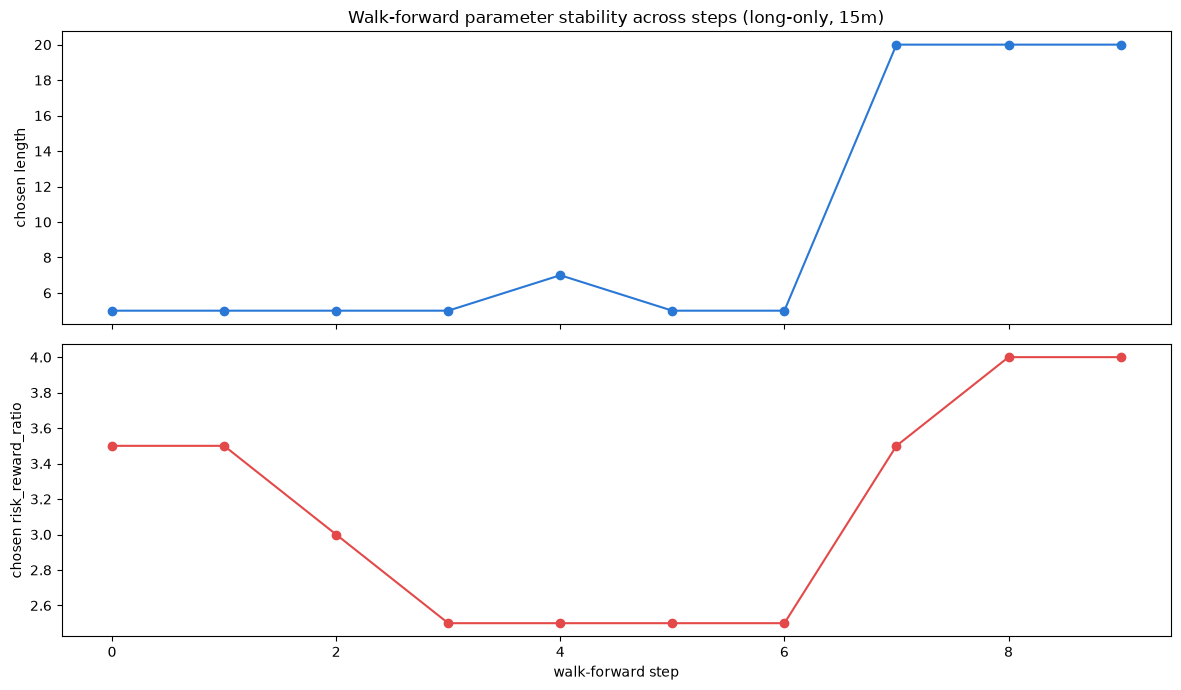

length: unique values chosen = [np.int64(5), np.int64(7), np.int64(20)]
risk_reward_ratio: unique values chosen = [np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0)]


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(wf_results["step"], wf_results["chosen_length"], marker="o", color="#2a78d6")
axes[0].set_ylabel("chosen length")
axes[0].set_title("Walk-forward parameter stability across steps (long-only, 15m)")
axes[1].plot(wf_results["step"], wf_results["chosen_rr"], marker="o", color="#e34948")
axes[1].set_ylabel("chosen risk_reward_ratio")
axes[1].set_xlabel("walk-forward step")
fig.tight_layout()
plt.show()

print(f"length: unique values chosen = {sorted(wf_results['chosen_length'].unique())}")
print(f"risk_reward_ratio: unique values chosen = {sorted(wf_results['chosen_rr'].unique())}")


### The real track record: concatenated out-of-sample trades


In [13]:
wf_trade_sharpe, wf_trade_sharpe_lb, wf_n = trade_sharpe_lb(wf_oos_trades)
wf_wins = sum(1 for t in wf_oos_trades if t.pnl > 0)
wf_win_rate = (wf_wins / wf_n * 100) if wf_n else float("nan")
wf_total_pnl_percent = sum(t.pnl for t in wf_oos_trades) * 100

print(f"Concatenated OOS trades across all {len(wf_steps)} steps: {wf_n}")
print(f"OOS win rate: {wf_win_rate:.2f}%")
print(f"OOS trade_sharpe: {wf_trade_sharpe:.4f}")
print(f"OOS trade_sharpe_lb: {wf_trade_sharpe_lb:.4f}")
print(f"OOS sum of trade pnl (frictionless, %): {wf_total_pnl_percent:.2f}%")


Concatenated OOS trades across all 10 steps: 944
OOS win rate: 27.65%
OOS trade_sharpe: 0.0567
OOS trade_sharpe_lb: 0.0032
OOS sum of trade pnl (frictionless, %): 59.78%


## Walk-forward conclusion

**First positive out-of-sample `trade_sharpe_lb` in this repo's entire research
program.** Every other walk-forward or holdout result tested across every
strategy so far (5-minute Donchian, S/R+psych breakout, Bollinger squeeze,
Keltner squeeze, SuperTrend flip) had a lower bound at or below zero -- this is
the first time it's crossed above.

**Concatenated OOS track record, 944 trades across all 10 steps (2021-05 to
2026-05, 5 years, none of which the parameter selection for that step ever
saw)**:

| metric | value |
|---|---|
| OOS trades | 944 |
| OOS win rate | 27.7% |
| OOS `trade_sharpe` (point estimate) | +0.057 |
| OOS `trade_sharpe_lb` | **+0.0032** |
| OOS sum of trade pnl (frictionless) | +59.8% |

7 of 10 steps had a positive OOS net return; the 3 negative steps were mild
(-5.1%, -2.7%, -1.0%), not catastrophic. Compare this to the 5-minute
Donchian walk-forward's best result (`trade_sharpe_lb=-0.046`, point estimate
+0.027) -- both the point estimate and the lower bound are meaningfully better
here.

**Parameter stability, with a real regime shift worth noting**: `length`
chosen was 5 in 6 of the first 7 steps (2021-2024), then shifted to 20 for the
last 3 steps (2024-11 onward, steps 7-9) -- not wild, isolated noise, but a
genuine drift toward a longer lookback in more recent history, and performance
stayed solidly positive through that shift (steps 7-9 net returns: +3.3%,
+10.8%, +0.7%). `risk_reward_ratio` stayed in a tighter, more stable {2.5,
3.0, 3.5, 4.0} range throughout.

**Calibrating the excitement**: `trade_sharpe_lb=+0.0032` is barely above
zero -- this clears the statistical bar, but only just. It's the first result
in this whole program to do so, which is meaningful, but it isn't a
strong edge by any stretch; z=1.645 (~95% one-sided) is a real but not
overwhelming confidence level, and 944 trades is a moderate, not huge, sample.
**Honest bottom line**: `direction=long` Donchian breakout on 15-minute MES
bars, short lookback (5-20 bars) with a 2.5-4x R:R, is the first strategy
configuration in this repo's research program with statistically defensible
(if modest) evidence of a real edge, rather than a promising number that
collapsed under scrutiny. Worth treating as a genuine candidate for further
work (smaller position sizing / paper trading to build more live confidence,
or extending history further back), not as a fully proven system.
